In [3]:
import pandas as pd
from google.colab import files
uploaded = files.upload()   # ev_data.csv 선택

df_e = pd.read_csv('ev_data.csv')
df_e['fault_name']  = df_e['fault_name'].astype(str).str.strip()
df_e['wafer_names'] = df_e['wafer_names'].astype(str).str.strip()

ev_vars = [c for c in df_e.columns if c not in ['Time','Step Number','wafer_names','fault_name']]
print(f"형태: {df_e.shape} | EV변수: {len(ev_vars)} | 웨이퍼: {df_e['wafer_names'].nunique()} | 결측치: {int(df_e.isna().sum().sum())}")
print(f"Step 분포: {dict(df_e['Step Number'].value_counts().sort_index())}")
print(f"웨이퍼별 행수: {df_e.groupby('wafer_names').size().describe()[['min','50%','max']].astype(int).to_dict()}")
print(f"fault 종류: {df_e['fault_name'].nunique()}")

# 단계별 행수 통계
step_counts = df_e.groupby(['wafer_names','Step Number']).size().unstack(fill_value=0)
print(f"\nStep 4 행수 (중앙값): {int(step_counts[4.0].median())} | Step 5 행수 (중앙값): {int(step_counts[5.0].median())}")

# 짧은 웨이퍼 후보 점검
short_wafers = df_e.groupby('wafer_names').size()
print(f"\n행수 < 20인 비정상 웨이퍼: {(short_wafers < 20).sum()}장")
if (short_wafers < 20).sum() > 0:
    print(short_wafers[short_wafers < 20].to_dict())

Saving ev_data.csv to ev_data (2).csv
형태: (12829, 23) | EV변수: 19 | 웨이퍼: 129 | 결측치: 0
Step 분포: {4.0: np.int64(6025), 5.0: np.int64(6804)}
웨이퍼별 행수: {'min': 3, '50%': 100, 'max': 112}
fault 종류: 21

Step 4 행수 (중앙값): 47 | Step 5 행수 (중앙값): 53

행수 < 20인 비정상 웨이퍼: 1장
{'l3125.txm': 3}


In [4]:
import re

def wafer_id(name):
    m = re.search(r'\d+', str(name))
    return m.group() if m else None

ev_ids = set(wafer_id(w) for w in df_e['wafer_names'].unique())
print(f"EV 웨이퍼 ID 수: {len(ev_ids)}")

# RFM 데이터에서 ID 추출 (X_df는 이전 RFM 단계에서 만든 변수)
try:
    rfm_ids = set(wafer_id(w) for w in X_df.index)
    oes_ids = set(wafer_id(w) for w in X_o_df.index)
    common = ev_ids & rfm_ids & oes_ids
    print(f"RFM ID: {len(rfm_ids)}, OES ID: {len(oes_ids)}")
    print(f"세 블록 공통 ID: {len(common)}")
    print(f"EV에만 있음: {len(ev_ids - rfm_ids - oes_ids)}")
    print(f"RFM/OES에만 있고 EV에 없음: {len((rfm_ids | oes_ids) - ev_ids)}")
except NameError:
    print("RFM/OES 변수가 없어 매칭 점검 스킵 (코랩 세션 재시작 후라면 이전 단계 일부 재실행 필요)")

EV 웨이퍼 ID 수: 129
RFM/OES 변수가 없어 매칭 점검 스킵 (코랩 세션 재시작 후라면 이전 단계 일부 재실행 필요)


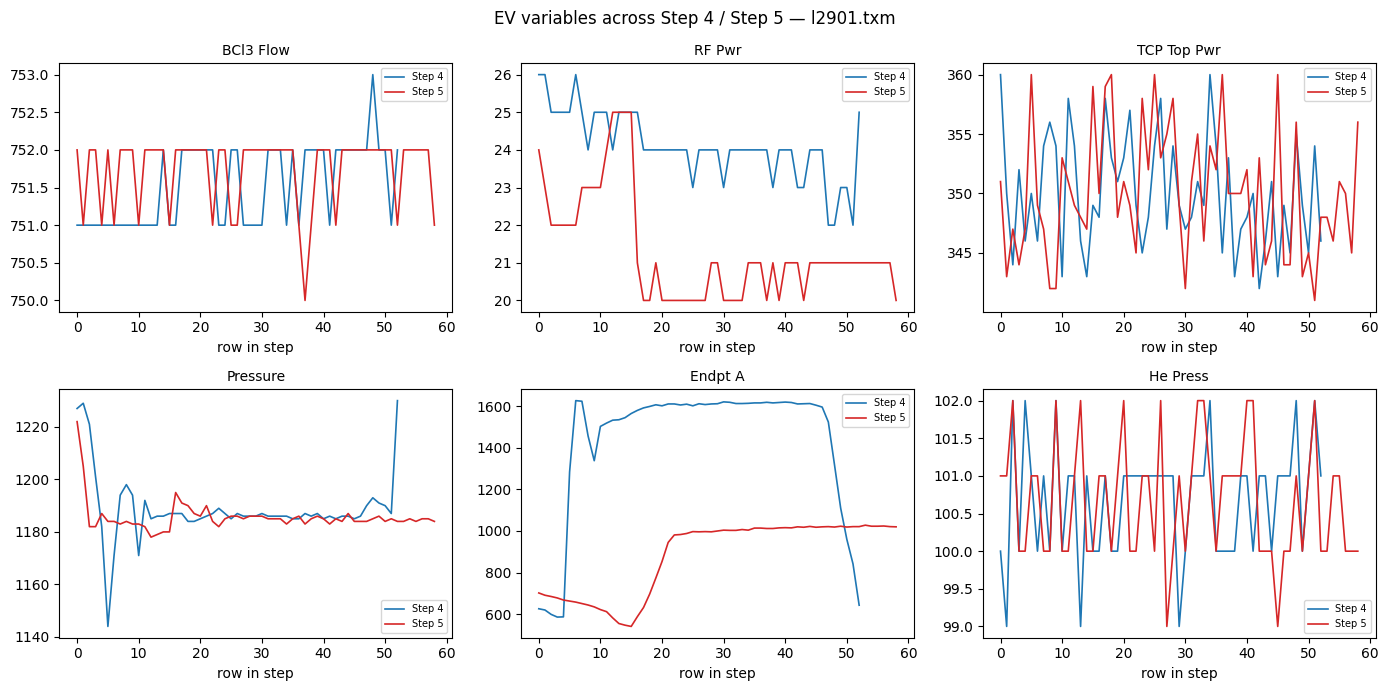

In [6]:
import matplotlib.pyplot as plt
sample = df_e['wafer_names'].iloc[0]
g = df_e[df_e['wafer_names']==sample].reset_index(drop=True)

# 어떤 변수가 Step 4와 5에서 다른 양상인지 6개 대표 변수로 확인
show = ['BCl3 Flow','RF Pwr','TCP Top Pwr','Pressure','Endpt A','He Press']
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
for ax, v in zip(axes, show):
    for step, color in [(4.0,'#1f77b4'), (5.0,'#d62728')]:
        gs = g[g['Step Number']==step]
        ax.plot(range(len(gs)), gs[v].values, label=f'Step {int(step)}', color=color, lw=1.2)
    ax.set_title(v, fontsize=10); ax.set_xlabel('row in step'); ax.legend(fontsize=7)
fig.suptitle(f'EV variables across Step 4 / Step 5 — {sample}')
plt.tight_layout(); plt.show()

In [8]:
import numpy as np
# 행수 부족 웨이퍼 점검 및 제외
short = df_e.groupby('wafer_names').size()
exclude = short[short < 20].index.tolist()
print(f"제외 웨이퍼: {exclude}")
for w in exclude:
    print(f"  {w}: fault = '{df_e.loc[df_e['wafer_names']==w, 'fault_name'].iloc[0]}'")

df_e_clean = df_e[~df_e['wafer_names'].isin(exclude)].copy()

K4, K5 = 47, 53
grid4 = np.linspace(0, 1, K4)
grid5 = np.linspace(0, 1, K5)

wafers_e, labels_e, blocks = [], [], []
for name, g in df_e_clean.groupby('wafer_names', sort=False):
    g4 = g[g['Step Number']==4.0].sort_values('Time')
    g5 = g[g['Step Number']==5.0].sort_values('Time')
    if len(g4) < 2 or len(g5) < 2:
        print(f"  단계 부족 스킵: {name} (Step4={len(g4)}, Step5={len(g5)})")
        continue
    tn4 = np.linspace(0, 1, len(g4))
    tn5 = np.linspace(0, 1, len(g5))
    m4 = np.column_stack([np.interp(grid4, tn4, g4[v].values) for v in ev_vars])  # (47, 19)
    m5 = np.column_stack([np.interp(grid5, tn5, g5[v].values) for v in ev_vars])  # (53, 19)
    blocks.append(np.vstack([m4, m5]))                                              # (100, 19)
    wafers_e.append(name); labels_e.append(g['fault_name'].iloc[0])

tensor_e = np.stack(blocks)                                                          # (N, 100, 19)
label_e  = pd.Series(labels_e, index=wafers_e, name='fault_name')
print(f"\n3D 텐서: {tensor_e.shape}  (웨이퍼 × (Step4+Step5 시점) × 변수)")
print(f"정상: {int((label_e=='calibration').sum())} | 이상: {int((label_e!='calibration').sum())}")

제외 웨이퍼: ['l3125.txm']
  l3125.txm: fault = 'calibration'

3D 텐서: (128, 100, 19)  (웨이퍼 × (Step4+Step5 시점) × 변수)
정상: 107 | 이상: 21


In [11]:
K_e = K4 + K5
feat_cols_e = [f"{v}_t{k:02d}" for v in ev_vars for k in range(K_e)]
X_e = tensor_e.transpose(0, 2, 1).reshape(tensor_e.shape[0], -1)   # (N, 19*100=1900)
X_e_df = pd.DataFrame(X_e, index=wafers_e, columns=feat_cols_e)
X_e_df.index.name = 'wafer_names'

cal_idx_e = label_e[label_e == 'calibration'].index
mu_e = X_e_df.loc[cal_idx_e].mean()
sd_e = X_e_df.loc[cal_idx_e].std().replace(0, 1).fillna(1)
X_e_z = (X_e_df - mu_e) / sd_e

print(f"펼친 행렬: {X_e_df.shape}")
print(f"X_e_z  NaN: {int(X_e_z.isna().sum().sum())}, inf: {int(np.isinf(X_e_z.values).sum())}")

펼친 행렬: (128, 1900)
X_e_z  NaN: 0, inf: 0


In [12]:
def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    if not np.all(np.isfinite(x)): return np.nan
    x = x - x.mean()
    denom = (x*x).sum()
    return float((x[:-1]*x[1:]).sum()/denom) if denom > 1e-12 else 0.0

fault_idx_e = label_e[label_e != 'calibration'].index
rows = []
for v in ev_vars:
    cols = [f"{v}_t{k:02d}" for k in range(K_e)]
    ac = float(np.nanmean([lag1_autocorr(X_e_df.loc[w, cols].values) for w in cal_idx_e]))
    fr = float(X_e_z.loc[fault_idx_e, cols].abs().mean().mean())
    rows.append({'variable': v, 'autocorr': round(ac, 3), 'fault_response': round(fr, 3)})
decision_e = pd.DataFrame(rows).set_index('variable')

print("=== autocorr 분포 ===")
print(decision_e['autocorr'].describe(percentiles=[.1,.5,.9]).round(3))
print("\n=== fault_response 분포 ===")
print(decision_e['fault_response'].describe(percentiles=[.1,.5,.9,.95,.99]).round(3))

ac_thr = 0.35
fr_low  = decision_e['fault_response'].quantile(0.20)
fr_high = decision_e['fault_response'].quantile(0.80)
decision_e['verdict'] = np.where(
    (decision_e['autocorr'] < ac_thr) & (decision_e['fault_response'] < fr_low), '제거후보',
    np.where(decision_e['fault_response'] >= fr_high, '강한신호', '유지'))

print(f"\n적용 임계값: autocorr<{ac_thr}, fault_response<{fr_low:.2f}(둔감) / ≥{fr_high:.2f}(강한신호)")
print("\n=== 변수별 진단 (fault_response 큰 순, 전체 19개) ===")
print(decision_e.sort_values('fault_response', ascending=False))
print(f"\n요약: {decision_e['verdict'].value_counts().to_dict()}")

=== autocorr 분포 ===
count    19.000
mean      0.464
std       0.313
min       0.080
10%       0.152
50%       0.330
90%       0.897
max       0.961
Name: autocorr, dtype: float64

=== fault_response 분포 ===
count    19.000
mean      1.178
std       0.964
min       0.293
10%       0.739
50%       0.857
90%       1.701
95%       2.802
99%       4.313
max       4.691
Name: fault_response, dtype: float64

적용 임계값: autocorr<0.35, fault_response<0.77(둔감) / ≥1.12(강한신호)

=== 변수별 진단 (fault_response 큰 순, 전체 19개) ===
                autocorr  fault_response verdict
variable                                        
BCl3 Flow          0.328           4.691    강한신호
Vat Valve          0.882           2.592    강한신호
RF Load            0.442           1.478    강한신호
TCP Tuner          0.912           1.187    강한신호
RF Tuner           0.330           1.072      유지
RF Pwr             0.855           1.060      유지
Pressure           0.640           0.982      유지
RF Impedance       0.523           0.925      유지


In [13]:
drop_vars_e = ['RF Btm Rfl Pwr', 'TCP Rfl Pwr']   # 데드 채널만 제거
keep_vars_e = [v for v in ev_vars if v not in drop_vars_e]
keep_cols_e = [f"{v}_t{k:02d}" for v in keep_vars_e for k in range(K_e)]

Xk_e = X_e_df[keep_cols_e].copy()
mu_ek = Xk_e.loc[cal_idx_e].mean()
sd_ek = Xk_e.loc[cal_idx_e].std().replace(0, 1).fillna(1)
Xkz_e = (Xk_e - mu_ek) / sd_ek

print(f"제거: {drop_vars_e} -> 유지 {len(keep_vars_e)}개 변수")
print(f"특징행렬: {Xkz_e.shape}  ({len(keep_vars_e)} 변수 × {K_e} 시점 = {len(keep_vars_e)*K_e})")

제거: ['RF Btm Rfl Pwr', 'TCP Rfl Pwr'] -> 유지 17개 변수
특징행렬: (128, 1700)  (17 변수 × 100 시점 = 1700)


/tmp/ipykernel_2567/2372564355.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


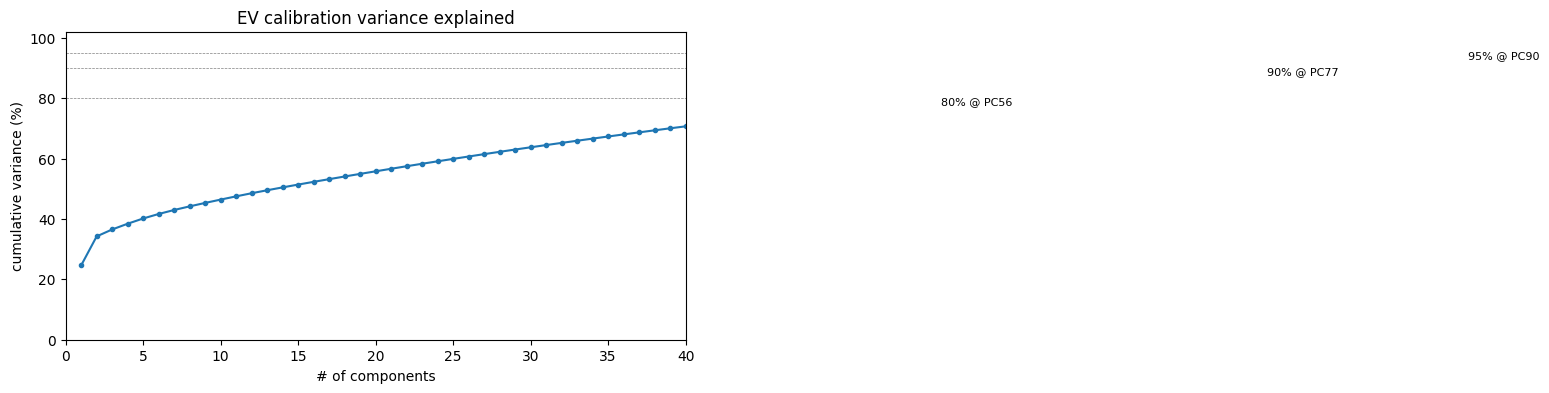

선택된 주성분 수 A_e = 77  | PC1 단독: 24.6%


In [14]:
from sklearn.decomposition import PCA

X_e_cal = Xkz_e.loc[cal_idx_e].values
pca_e_full = PCA().fit(X_e_cal)
cum_e = np.cumsum(pca_e_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_e)+1), cum_e*100, 'o-', ms=3)
for thr in [80, 90, 95]:
    n = int(np.searchsorted(cum_e, thr/100)) + 1
    ax.axhline(thr, color='gray', ls='--', lw=.5)
    ax.text(n+0.5, thr-2, f"{thr}% @ PC{n}", fontsize=8)
ax.set_xlabel('# of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_xlim(0, 40); ax.set_ylim(0, 102)
ax.set_title('EV calibration variance explained')
plt.tight_layout(); plt.show()

A_e = int(np.searchsorted(cum_e, 0.90)) + 1
print(f"선택된 주성분 수 A_e = {A_e}  | PC1 단독: {pca_e_full.explained_variance_ratio_[0]*100:.1f}%")

한계선: T² > 98.79, Q > 358.25
탐지 21/21  |  정상 오탐 4/107

=== 이상 웨이퍼별 탐지 결과 ===
   fault      T2         Q  T2_hit  Q_hit  any_hit
 BCl3 -5 4150.59 411697.79    True   True     True
   RF +8  829.62  67840.32    True   True     True
   Pr +3  263.11   8529.97    True   True     True
   Pr -2  204.43   6938.28    True   True     True
   Pr +2  145.57   4951.71    True   True     True
 TCP +50   30.31   2598.29   False   True     True
 TCP +30   22.28   2350.64   False   True     True
BCl3 +10   62.02   2202.34   False   True     True
 TCP -20   22.91   2046.75   False   True     True
 TCP -15   21.16   1738.35   False   True     True
   Pr +1   40.82   1611.65   False   True     True
 TCP +20   21.07   1461.27   False   True     True
 Cl2 -10   24.16   1324.86   False   True     True
He Chuck   13.69   1321.12   False   True     True
  RF -12   13.07   1167.93   False   True     True
  RF -12   10.67   1164.35   False   True     True
  Cl2 +5   13.03   1086.23   False   True     True
  Cl2 

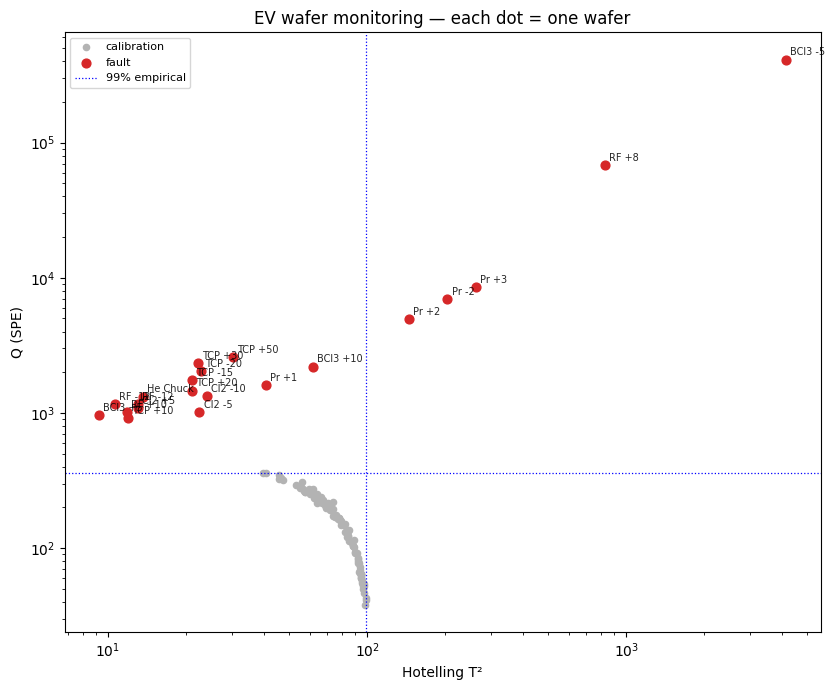

In [15]:
pca_e = PCA(n_components=A_e).fit(X_e_cal)
T_e   = pca_e.transform(Xkz_e.values)
res_e = Xkz_e.values - pca_e.inverse_transform(T_e)
T2_e  = (T_e**2 / pca_e.explained_variance_).sum(axis=1)
Q_e   = (res_e**2).sum(axis=1)

is_fault_e = (label_e != 'calibration').values
T2_lim_e = np.quantile(T2_e[~is_fault_e], 0.99)
Q_lim_e  = np.quantile(Q_e [~is_fault_e], 0.99)
hit_e = (T2_e > T2_lim_e) | (Q_e > Q_lim_e)

ft_e = pd.DataFrame({
    'fault': label_e.values, 'T2': T2_e.round(2), 'Q': Q_e.round(2),
    'T2_hit': T2_e > T2_lim_e, 'Q_hit': Q_e > Q_lim_e, 'any_hit': hit_e,
}, index=label_e.index)
ft_e = ft_e[ft_e['fault']!='calibration'].sort_values('Q', ascending=False)

print(f"한계선: T² > {T2_lim_e:.2f}, Q > {Q_lim_e:.2f}")
print(f"탐지 {int(hit_e[is_fault_e].sum())}/{int(is_fault_e.sum())}  |  정상 오탐 {int(hit_e[~is_fault_e].sum())}/{int((~is_fault_e).sum())}")
print("\n=== 이상 웨이퍼별 탐지 결과 ===")
print(ft_e[['fault','T2','Q','T2_hit','Q_hit','any_hit']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(T2_e[~is_fault_e], Q_e[~is_fault_e], s=20, c='0.7', label='calibration')
ax.scatter(T2_e[is_fault_e],  Q_e[is_fault_e],  s=40, c='#d62728', label='fault')
for i in np.where(is_fault_e)[0]:
    ax.annotate(label_e.iloc[i], (T2_e[i], Q_e[i]), fontsize=7,
                xytext=(3,3), textcoords='offset points', alpha=.85)
ax.axvline(T2_lim_e, color='b', ls=':', lw=.9, label='99% empirical')
ax.axhline(Q_lim_e,  color='b', ls=':', lw=.9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Hotelling T²'); ax.set_ylabel('Q (SPE)')
ax.set_title('EV wafer monitoring — each dot = one wafer')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
Xkz_e.to_csv('ev_block_features.csv')

scores_e = pd.DataFrame({
    'fault_name': label_e.values,
    'T2_ev': T2_e, 'Q_ev': Q_e, 'hit_ev': hit_e,
}, index=label_e.index)
scores_e.index.name = 'wafer_names'
scores_e.to_csv('ev_block_scores.csv')

print(f"저장:")
print(f"  ev_block_features.csv  {Xkz_e.shape}")
print(f"  ev_block_scores.csv    탐지 {int(hit_e[is_fault_e].sum())}/{int(is_fault_e.sum())}, 오탐 {int(hit_e[~is_fault_e].sum())}/{int((~is_fault_e).sum())}")

from google.colab import files
files.download('ev_block_features.csv')
files.download('ev_block_scores.csv')

저장:
  ev_block_features.csv  (128, 1700)
  ev_block_scores.csv    탐지 21/21, 오탐 4/107


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>